In [1]:
import math
from math import ceil, sqrt
from typing import List, Optional, Tuple, Dict, Any

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle, Circle
from hydrax.utils.files import get_data_path
import pandas as pd
import pprint
from hydrax.utils.files import get_data_path
import seaborn as sns

from matplotlib.ticker import FuncFormatter


In [20]:
import pickle

# path = get_data_path().parent / "experiments" / "online_dr_sim"
path = get_data_path() / "dr_sim" 
seeds = [42] 
controllers = ["anmtp"] #["anmtp", "mtp", "mpc"]
dr_strategies = ["uniform"] #["evolutionary", "uniform", "bayesian"]
aggregation = ["expectation", "average"]  #["expectation", "average", "icvar"]

data = {}

for seed in seeds:
    for controller in controllers:
        data[controller] = {}
        for dr_strategy in dr_strategies:
            data[controller][dr_strategy] = {}
            for agg in aggregation:
                data[controller][dr_strategy][agg] = {}
                pkl_path = path / f"seed_{seed}_{controller}_{dr_strategy}_{agg}.pkl"
                with open(pkl_path, "rb") as f:
                    logs = pickle.load(f)
                    weights = []
                    costs = []
                    for step in logs:
                        weights.append(step["domain_weights"])
                        costs.append(step["state_cost"])
                        
                    # to numpy array
                    data[controller][dr_strategy][agg]["weights"] = np.array(weights)
                    data[controller][dr_strategy][agg]["costs"] = np.array(costs)

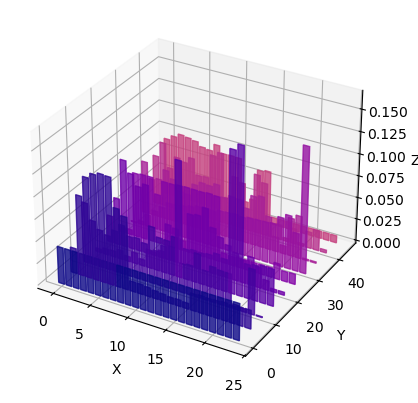

In [26]:
weights = data["anmtp"]["uniform"]["expectation"]["weights"]

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

cmap = plt.get_cmap("plasma")  # any colormap name
N = 20
steps = [x * 5 for x in range(10)] #np.linspace(0, weights.shape[0] - 1, N, dtype=int)


colors = [cmap(i / (N - 1)) for i in range(N)]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
nbins = 24
for c, z in zip(colors, steps):
    ys = np.random.normal(loc=10, scale=10, size=2000)

    hist = weights[z, :]
    bins = np.arange(nbins + 1) - 0.5
    xs = (bins[:-1] + bins[1:])/2

    ax.bar(xs, hist, zs=z, zdir='y', color=c, ec=c, alpha=0.8)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

Text(0, 0.5, 'Average Weight')

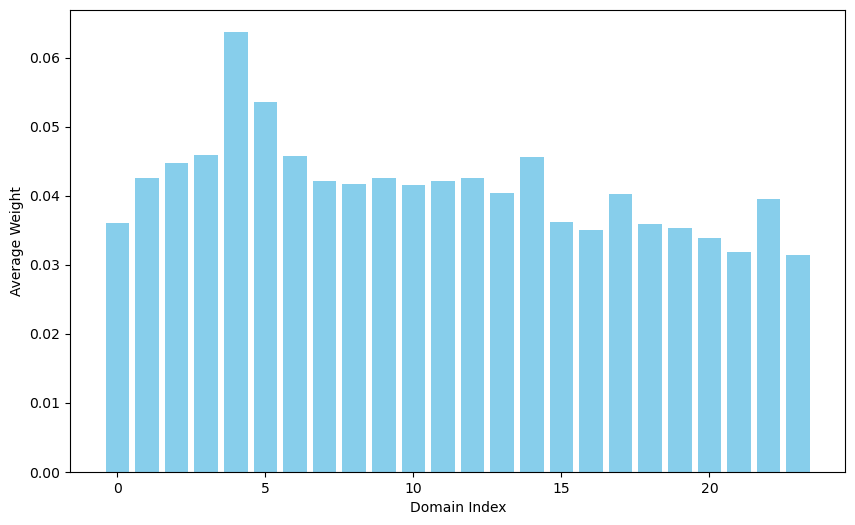

In [22]:
mean_weights = np.mean(weights, axis=0)
# histogram plot
plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(mean_weights)), mean_weights, color='skyblue')
plt.xlabel('Domain Index')
plt.ylabel('Average Weight')

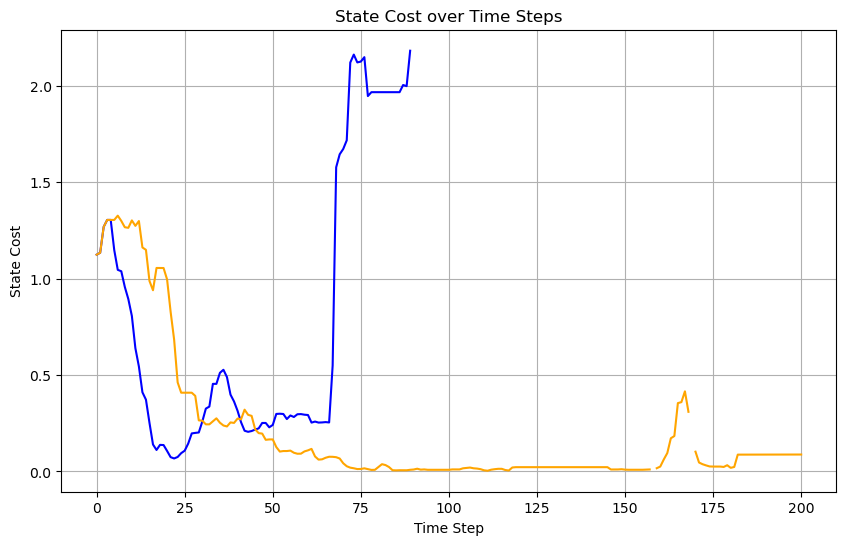

In [24]:
costs = data["anmtp"]["uniform"]["expectation"]["costs"]
costs2 = data["anmtp"]["uniform"]["average"]["costs"]
plt.figure(figsize=(10, 6))
plt.plot(costs2, color='blue', label='Average Aggregation')
plt.plot(costs, color='orange', label='Expectation Aggregation')

plt.xlabel('Time Step')
plt.ylabel('State Cost')
plt.title('State Cost over Time Steps')
plt.grid()
plt.show()